C:\Users\18038\AppData\Local\Temp\ipykernel_28552\3059219973.py:187: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


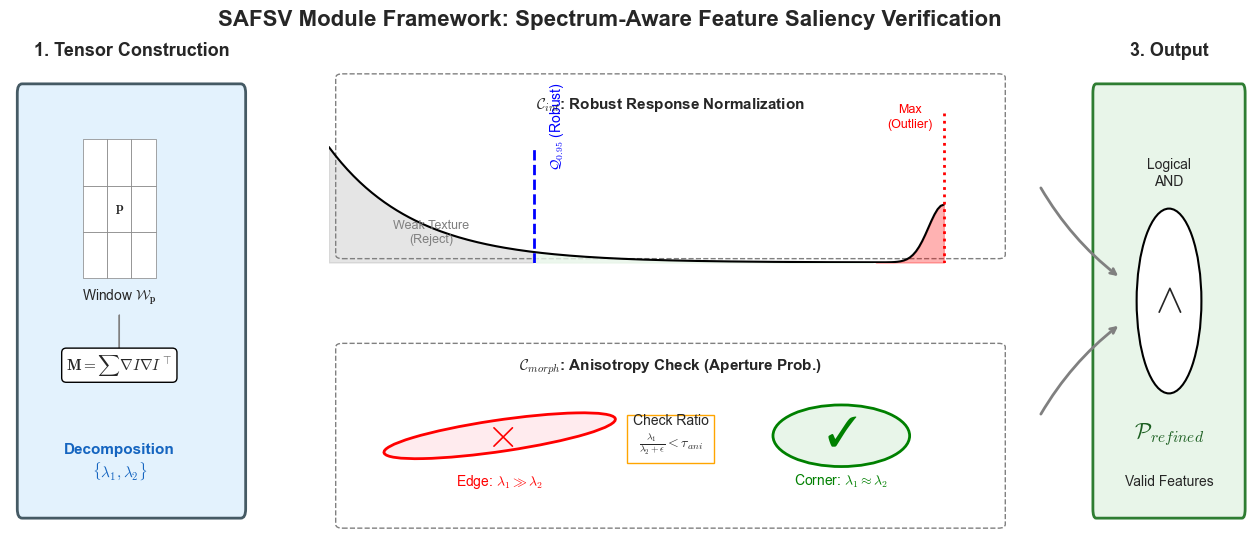

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import matplotlib.gridspec as gridspec
from matplotlib.path import Path

# ==========================================
# 1. 样式与画布设置
# ==========================================
plt.style.use('seaborn-v0_8-white')
plt.rcParams['font.family'] = 'sans-serif' # 框架图通常用无衬线字体更现代
plt.rcParams['mathtext.fontset'] = 'cm'    # 数学公式使用 LaTeX 风格

# 创建宽画布
fig = plt.figure(figsize=(16, 6))
# 定义布局：左(1) -> 中(2) -> 右(1)
gs = gridspec.GridSpec(2, 4, width_ratios=[1.2, 1.5, 1.5, 0.8], wspace=0.3, hspace=0.4)

# 定义颜色
c_input = '#E3F2FD'   # 浅蓝
c_proc = '#FFF3E0'    # 浅橙
c_valid = '#E8F5E9'   # 浅绿
c_rej = '#FFEBEE'     # 浅红
c_border = '#455A64'  # 深灰边框
c_accent = '#1565C0'  # 强调色

# ==========================================
# 模块 1: 输入与结构张量 (Input & Tensor)
# ==========================================
ax1 = fig.add_subplot(gs[:, 0])
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')

# 绘制背景框
box1 = patches.FancyBboxPatch((0.5, 0.5), 9, 9, boxstyle="round,pad=0.2", 
                              fc=c_input, ec=c_border, lw=2)
ax1.add_patch(box1)

# 1.1 绘制像素网格 (W_p)
grid_x, grid_y = 3, 5.5
for i in range(3):
    for j in range(3):
        rect = patches.Rectangle((grid_x + i, grid_y + j), 1, 1, 
                                 fc='white', ec='gray', lw=0.5)
        ax1.add_patch(rect)
# 标注中心点 p
ax1.text(grid_x + 1.5, grid_y + 1.5, r'$\mathbf{p}$', ha='center', va='center', fontweight='bold')
ax1.text(grid_x + 1.5, grid_y - 0.5, r'Window $\mathcal{W}_\mathbf{p}$', ha='center', fontsize=10)

# 1.2 箭头向下
ax1.arrow(grid_x + 1.5, grid_y - 0.8, 0, -1.0, head_width=0.3, head_length=0.3, fc='gray', ec='gray')

# 1.3 绘制结构张量矩阵 M
ax1.text(grid_x + 1.5, 3.5, r'$\mathbf{M} = \sum \nabla I \nabla I^\top$', 
         ha='center', fontsize=11, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

# 1.4 分解结果 (特征值)
ax1.text(grid_x + 1.5, 1.5, r'Decomposition' + '\n' + r'$\{\lambda_1, \lambda_2\}$', 
         ha='center', va='center', fontsize=11, fontweight='bold', color=c_accent)

# 标题
ax1.set_title("1. Tensor Construction", fontsize=13, fontweight='bold', pad=10)


# ==========================================
# 模块 2A (上): 强度约束 (Intensity Constraint)
# ==========================================
ax2a = fig.add_subplot(gs[0, 1:3]) # 跨两列
ax2a.set_xlim(0, 10)
ax2a.set_ylim(0, 5)
ax2a.axis('off')

# 背景
box2a = patches.FancyBboxPatch((0.2, 0.2), 9.6, 4.6, boxstyle="round,pad=0.1", 
                               fc='white', ec='gray', lw=1, linestyle='--')
ax2a.add_patch(box2a)

# 绘制长尾分布示意图
x = np.linspace(0, 9, 200)
y = 3 * np.exp(-0.8 * x) # 长尾分布
y[180:] += 1.5 * np.exp(-10*(x[180:]-9)**2) # 添加极右侧的高光 Outlier

# 绘制填充区域
# 弱纹理区域 (Reject)
ax2a.fill_between(x[x<3], y[x<3], color='gray', alpha=0.2)
# 有效区域 (Accept)
ax2a.fill_between(x[(x>=3) & (x<8)], y[(x>=3) & (x<8)], color=c_valid, alpha=0.8)
# Outlier区域 (虽然数值高，但归一化时是干扰项)
ax2a.fill_between(x[x>=8], y[x>=8], color='red', alpha=0.3)

# 绘制曲线
ax2a.plot(x, y, color='black', lw=1.5)

# 标注关键点
# 95% 分位数
ax2a.axvline(x=3, ymin=0, ymax=0.6, color='blue', linestyle='--', lw=2)
ax2a.text(3.2, 2.5, r'$\mathcal{Q}_{0.95}$ (Robust)', color='blue', fontsize=10, rotation=90)

# Max 值
ax2a.axvline(x=9, ymin=0, ymax=0.8, color='red', linestyle=':', lw=2)
ax2a.text(8.5, 3.5, 'Max\n(Outlier)', color='red', fontsize=9, ha='center')

# 公式与说明
ax2a.text(5, 4, r'$\mathcal{C}_{int}$: Robust Response Normalization', fontsize=11, ha='center', fontweight='bold')
ax2a.text(1.5, 0.5, 'Weak Texture\n(Reject)', fontsize=9, color='gray', ha='center')

# ==========================================
# 模块 2B (下): 形态约束 (Morphology Constraint)
# ==========================================
ax2b = fig.add_subplot(gs[1, 1:3])
ax2b.set_xlim(0, 10)
ax2b.set_ylim(0, 5)
ax2b.axis('off')

# 背景
box2b = patches.FancyBboxPatch((0.2, 0.2), 9.6, 4.6, boxstyle="round,pad=0.1", 
                               fc='white', ec='gray', lw=1, linestyle='--')
ax2b.add_patch(box2b)

# 标题
ax2b.text(5, 4.2, r'$\mathcal{C}_{morph}$: Anisotropy Check (Aperture Prob.)', fontsize=11, ha='center', fontweight='bold')

# 左侧：Bad Case (Edge)
e_bad = patches.Ellipse((2.5, 2.5), 3.5, 0.8, angle=15, fc=c_rej, ec='red', lw=2)
ax2b.add_patch(e_bad)
ax2b.text(2.5, 1.2, r'Edge: $\lambda_1 \gg \lambda_2$', ha='center', color='red')
# 画个大红叉
ax2b.text(2.5, 2.5, r'$\times$', ha='center', va='center', fontsize=30, color='red')

# 右侧：Good Case (Corner)
e_good = patches.Ellipse((7.5, 2.5), 2.0, 1.6, angle=0, fc=c_valid, ec='green', lw=2)
ax2b.add_patch(e_good)
ax2b.text(7.5, 1.2, r'Corner: $\lambda_1 \approx \lambda_2$', ha='center', color='green')
# 画个大绿勾
ax2b.text(7.5, 2.5, r'$\checkmark$', ha='center', va='center', fontsize=30, color='green')

# 中间比较符
ax2b.text(5, 2.5, r'Check Ratio' + '\n' + r'$\frac{\lambda_1}{\lambda_2+\epsilon} < \tau_{ani}$', 
          ha='center', va='center', fontsize=10, bbox=dict(fc='white', ec='orange'))


# ==========================================
# 模块 3: 逻辑与 & 输出 (AND & Output)
# ==========================================
ax3 = fig.add_subplot(gs[:, 3])
ax3.set_xlim(0, 10)
ax3.set_ylim(0, 10)
ax3.axis('off')

# 背景
box3 = patches.FancyBboxPatch((0.5, 0.5), 9, 9, boxstyle="round,pad=0.2", 
                              fc=c_valid, ec='#2E7D32', lw=2)
ax3.add_patch(box3)

# AND Gate 符号
circle = patches.Circle((5, 5), 2, fc='white', ec='black', lw=1.5)
ax3.add_patch(circle)
ax3.text(5, 5, r'$\wedge$', fontsize=30, ha='center', va='center')
ax3.text(5, 7.5, 'Logical\nAND', ha='center', fontsize=10)

# 输出结果
ax3.text(5, 2, r'$\mathcal{P}_{refined}$', fontsize=16, fontweight='bold', ha='center', color='#1B5E20')
ax3.text(5, 1, 'Valid Features', fontsize=10, ha='center')

# 标题
ax3.set_title("3. Output", fontsize=13, fontweight='bold', pad=10)

# ==========================================
# 绘制连接箭头 (跨子图有点难，我们在各自坐标系边缘画)
# ==========================================

# 从 Mod 1 分出两路
# 在 ax1 右侧画分叉
ax1.annotate('', xy=(10.5, 7.5), xytext=(9, 5), arrowprops=dict(arrowstyle="->", lw=2, color='gray', connectionstyle="arc3,rad=0.2"))
ax1.annotate('', xy=(10.5, 2.5), xytext=(9, 5), arrowprops=dict(arrowstyle="->", lw=2, color='gray', connectionstyle="arc3,rad=-0.2"))

# 从 Mod 2 汇聚到 Mod 3
# 强度约束 -> AND
ax3.annotate('', xy=(2, 5.5), xytext=(-3, 7.5), xycoords='data', textcoords='data',
             arrowprops=dict(arrowstyle="->", lw=2, color='gray', connectionstyle="arc3,rad=0.1"))
# 形态约束 -> AND
ax3.annotate('', xy=(2, 4.5), xytext=(-3, 2.5), xycoords='data', textcoords='data',
             arrowprops=dict(arrowstyle="->", lw=2, color='gray', connectionstyle="arc3,rad=-0.1"))

plt.suptitle("SAFSV Module Framework: Spectrum-Aware Feature Saliency Verification", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('SAFSV_framework_diagram.pdf', bbox_inches='tight')
plt.show()

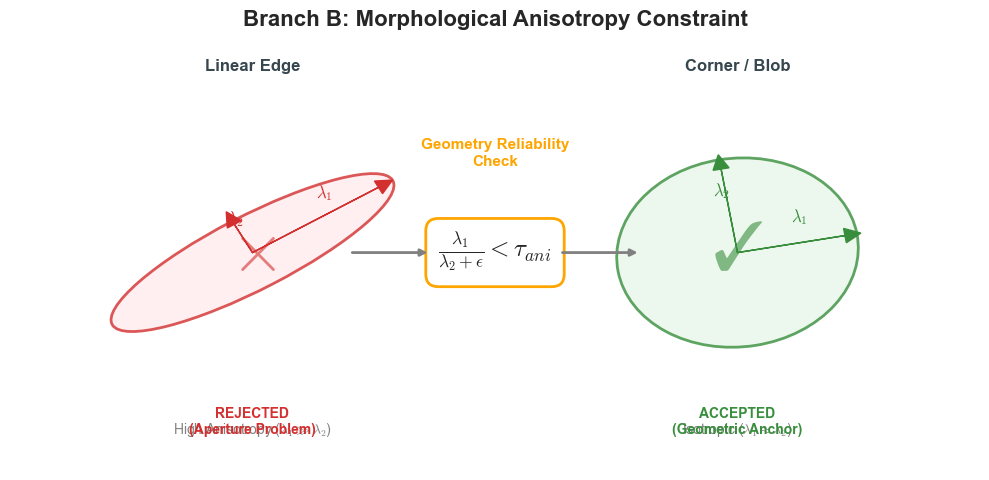

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# ==========================================
# 1. 样式设置
# ==========================================
plt.style.use('seaborn-v0_8-white')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['mathtext.fontset'] = 'cm'

# 创建画布
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis('off') # 隐藏坐标轴

# 定义颜色
c_edge = '#FFEBEE'     # 浅红背景 (Edge)
c_edge_stroke = '#D32F2F' # 深红线条
c_corner = '#E8F5E9'   # 浅绿背景 (Corner)
c_corner_stroke = '#388E3C' # 深绿线条
c_text = '#37474F'

# ==========================================
# 2. 辅助绘图函数 (绘制带特征向量的椭圆)
# ==========================================
def draw_eigen_ellipse(ax, center, l1, l2, angle_deg, color_bg, color_stroke, label_top, label_bottom):
    x, y = center
    angle_rad = np.radians(angle_deg)
    
    # 1. 绘制椭圆主体
    # 注意：matplotlib的width对应总长(2*lambda)，这里为了视觉比例我们适当调整
    ell = patches.Ellipse(center, width=l1*2, height=l2*2, angle=angle_deg, 
                          fc=color_bg, ec=color_stroke, lw=2, alpha=0.8)
    ax.add_patch(ell)
    
    # 2. 绘制特征向量 (箭头)
    # 主方向 lambda 1
    dx1 = (l1 * 0.9) * np.cos(angle_rad)
    dy1 = (l1 * 0.9) * np.sin(angle_rad)
    ax.arrow(x, y, dx1, dy1, head_width=0.2, head_length=0.2, fc=color_stroke, ec=color_stroke)
    # 标注 lambda 1
    ax.text(x + dx1*0.5, y + dy1*0.5 + 0.3, r'$\lambda_1$', color=color_stroke, fontweight='bold', fontsize=12)

    # 次方向 lambda 2
    dx2 = (l2 * 0.9) * np.cos(angle_rad + np.pi/2)
    dy2 = (l2 * 0.9) * np.sin(angle_rad + np.pi/2)
    ax.arrow(x, y, dx2, dy2, head_width=0.2, head_length=0.2, fc=color_stroke, ec=color_stroke)
    # 标注 lambda 2
    ax.text(x + dx2*0.5 - 0.2, y + dy2*0.5 + 0.2, r'$\lambda_2$', color=color_stroke, fontweight='bold', fontsize=12)

    # 3. 顶部和底部文字
    ax.text(x, y + 2.5, label_top, ha='center', fontsize=12, fontweight='bold', color=c_text)
    ax.text(x, y - 2.5, label_bottom, ha='center', fontsize=10, color='gray')

# ==========================================
# 3. 绘制左侧：边缘特征 (Bad Case)
# ==========================================
# 细长椭圆，lambda1 >> lambda2
draw_eigen_ellipse(ax, center=(3, 3), l1=2.0, l2=0.5, angle_deg=30, 
                   color_bg=c_edge, color_stroke=c_edge_stroke,
                   label_top="Linear Edge", 
                   label_bottom=r"High Anisotropy ($\lambda_1 \gg \lambda_2$)")

# 绘制大红叉
ax.text(3, 3, r'$\times$', ha='center', va='center', fontsize=50, color=c_edge_stroke, alpha=0.6)
ax.text(3, 0.5, "REJECTED\n(Aperture Problem)", ha='center', color=c_edge_stroke, fontweight='bold')

# ==========================================
# 4. 绘制右侧：角点特征 (Good Case)
# ==========================================
# 胖椭圆/圆形，lambda1 approx lambda2
draw_eigen_ellipse(ax, center=(9, 3), l1=1.5, l2=1.3, angle_deg=10, 
                   color_bg=c_corner, color_stroke=c_corner_stroke,
                   label_top="Corner / Blob", 
                   label_bottom=r"Isotropic ($\lambda_1 \approx \lambda_2$)")

# 绘制大绿勾
ax.text(9, 3, r'$\checkmark$', ha='center', va='center', fontsize=50, color=c_corner_stroke, alpha=0.6)
ax.text(9, 0.5, "ACCEPTED\n(Geometric Anchor)", ha='center', color=c_corner_stroke, fontweight='bold')

# ==========================================
# 5. 绘制中间：判别逻辑 (The Gate)
# ==========================================
# 绘制比率公式
bbox_props = dict(boxstyle="round,pad=0.5", fc="white", ec="orange", lw=2)
ax.text(6, 3, r'$\frac{\lambda_1}{\lambda_2 + \epsilon} < \tau_{ani}$', 
        ha='center', va='center', fontsize=18, bbox=bbox_props)

ax.text(6, 4.2, "Geometry Reliability\nCheck", ha='center', fontsize=11, fontweight='bold', color='orange')

# 绘制中间的分割线或箭头
ax.annotate('', xy=(5.2, 3), xytext=(4.2, 3), arrowprops=dict(arrowstyle="-|>", color='gray', lw=2))
ax.annotate('', xy=(7.8, 3), xytext=(6.8, 3), arrowprops=dict(arrowstyle="-|>", color='gray', lw=2))

# 标题
plt.suptitle("Branch B: Morphological Anisotropy Constraint", fontsize=16, fontweight='bold', y=0.95)

plt.tight_layout()
plt.show()
# plt.savefig('morphological_anisotropy.pdf', bbox_inches='tight')

C:\Users\18038\AppData\Local\Temp\ipykernel_28552\109085332.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


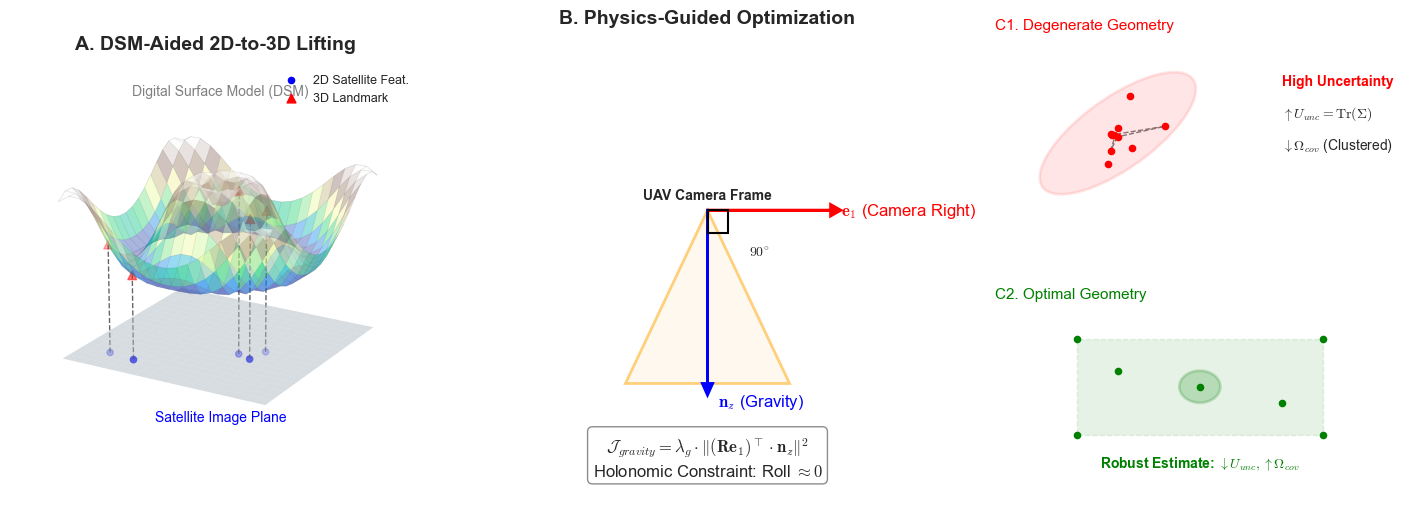

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import FancyArrowPatch, Ellipse, Polygon
from mpl_toolkits.mplot3d import proj3d

# 设置风格
plt.style.use('seaborn-v0_8-white')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['mathtext.fontset'] = 'cm'

fig = plt.figure(figsize=(18, 6))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1], wspace=0.2)

# ==========================================
# Panel A: 2D-to-3D Lifting with DSM
# ==========================================
ax1 = fig.add_subplot(gs[0], projection='3d')

# 1. 生成模拟地形 (DSM)
x = np.linspace(-2, 2, 20)
y = np.linspace(-2, 2, 20)
X, Y = np.meshgrid(x, y)
Z = 0.5 * np.sin(np.sqrt(X**2 + Y**2) * 3) + 1  # 波动的地形

# 2. 绘制地形网格
ax1.plot_wireframe(X, Y, Z, color='gray', alpha=0.3, linewidth=0.5)
ax1.plot_surface(X, Y, Z, cmap='terrain', alpha=0.4)

# 3. 绘制底面 (卫星影像平面)
Z_flat = np.zeros_like(Z) - 0.5
ax1.plot_surface(X, Y, Z_flat, color='#E3F2FD', alpha=0.5) # 浅蓝

# 4. 模拟特征点
num_pts = 5
px = np.random.uniform(-1.5, 1.5, num_pts)
py = np.random.uniform(-1.5, 1.5, num_pts)
pz_flat = np.zeros(num_pts) - 0.5
# 计算DSM上的高度
pz_dsm = 0.5 * np.sin(np.sqrt(px**2 + py**2) * 3) + 1

# 5. 绘制投影线和点
ax1.scatter(px, py, pz_flat, c='blue', s=20, label='2D Satellite Feat.')
ax1.scatter(px, py, pz_dsm, c='red', s=40, marker='^', label='3D Landmark')

for i in range(num_pts):
    ax1.plot([px[i], px[i]], [py[i], py[i]], [pz_flat[i], pz_dsm[i]], 'k--', alpha=0.6, linewidth=1)

ax1.set_title("A. DSM-Aided 2D-to-3D Lifting", fontsize=14, fontweight='bold', pad=10)
ax1.set_axis_off()
ax1.view_init(elev=20, azim=-60)
ax1.legend(loc='upper right', fontsize=9)
ax1.text(0, 0, -1.5, "Satellite Image Plane", ha='center', fontsize=10, color='blue')
ax1.text(0, 0, 2.5, "Digital Surface Model (DSM)", ha='center', fontsize=10, color='gray')


# ==========================================
# Panel B: Physics-Guided Constraints
# ==========================================
ax2 = fig.add_subplot(gs[1])
ax2.set_xlim(-2, 2)
ax2.set_ylim(-2, 2)
ax2.axis('off')

# 1. 绘制相机视锥 (示意无人机)
camera_center = np.array([0, 0.5])
# 视锥三角形
frustum = plt.Polygon([camera_center, [-0.8, -1], [0.8, -1]], 
                      closed=True, fc='#FFF3E0', ec='orange', lw=2, alpha=0.5)
ax2.add_patch(frustum)
ax2.text(0, 0.6, "UAV Camera Frame", ha='center', fontweight='bold')

# 2. 绘制坐标轴向量
# 相机右轴 e1 (Roll axis direction) - 假设此时是水平的
ax2.arrow(0, 0.5, 1.2, 0, head_width=0.1, head_length=0.1, fc='red', ec='red', lw=2)
ax2.text(1.3, 0.5, r'$\mathbf{e}_1$ (Camera Right)', color='red', fontsize=12, va='center')

# 重力反向向量 nz
ax2.arrow(0, 0.5, 0, -1.5, head_width=0.1, head_length=0.1, fc='blue', ec='blue', lw=2)
ax2.text(0.1, -1.2, r'$\mathbf{n}_z$ (Gravity)', color='blue', fontsize=12)

# 3. 绘制垂直约束符号
# 画一个小方块表示垂直
rect = plt.Rectangle((0, 0.3), 0.2, 0.2, fill=False, edgecolor='black', lw=1.5)
ax2.add_patch(rect)
ax2.text(0.4, 0.1, r'$90^{\circ}$', fontsize=10)

# 4. 添加公式注释
bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9)
eq_text = (r"$\mathcal{J}_{gravity} = \lambda_g \cdot \| (\mathbf{R}\mathbf{e}_1)^\top \cdot \mathbf{n}_z \|^2$" + "\n" +
           r"Holonomic Constraint: Roll $\approx 0$")
ax2.text(0, -1.8, eq_text, ha='center', fontsize=12, bbox=bbox_props)

ax2.set_title("B. Physics-Guided Optimization", fontsize=14, fontweight='bold', pad=10)


# ==========================================
# Panel C: Uncertainty & Coverage
# ==========================================
# 将右侧分为上下两部分
gs_right = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[2], hspace=0.4)

# --- Subplot C1: High Uncertainty (Bad) ---
ax3a = fig.add_subplot(gs_right[0])
ax3a.set_xlim(0, 10)
ax3a.set_ylim(0, 6)
ax3a.axis('off')

# 模拟聚集的点 (Low Spatial Coverage)
pts_bad = np.random.normal(loc=[3, 3], scale=0.5, size=(10, 2))
hull_bad = Polygon(pts_bad[np.array([0, 1, 3, 7, 9, 0])], closed=True, fc='none', ec='gray', linestyle='--') # 简化的凸包
ax3a.add_patch(hull_bad)
ax3a.scatter(pts_bad[:,0], pts_bad[:,1], c='red', s=20, label='Inliers')

# 绘制巨大的误差椭圆
ell_bad = Ellipse((3, 3), width=5, height=2, angle=45, fc='red', alpha=0.1, ec='red', lw=2)
ax3a.add_patch(ell_bad)

ax3a.text(7, 4.5, "High Uncertainty", color='red', fontweight='bold')
ax3a.text(7, 3.5, r"$\uparrow U_{unc} = \text{Tr}(\mathbf{\Sigma})$", fontsize=10)
ax3a.text(7, 2.5, r"$\downarrow \Omega_{cov}$ (Clustered)", fontsize=10)
ax3a.set_title("C1. Degenerate Geometry", fontsize=11, loc='left', color='red')

# --- Subplot C2: Low Uncertainty (Good) ---
ax3b = fig.add_subplot(gs_right[1])
ax3b.set_xlim(0, 10)
ax3b.set_ylim(0, 6)
ax3b.axis('off')

# 模拟分散的点 (High Spatial Coverage)
pts_good = np.array([[2,2], [8,2], [2,5], [8,5], [5,3.5], [3,4], [7,3]])
hull_good = Polygon([[2,2], [8,2], [8,5], [2,5]], closed=True, fc='green', alpha=0.1, ec='green', linestyle='--')
ax3b.add_patch(hull_good)
ax3b.scatter(pts_good[:,0], pts_good[:,1], c='green', s=20)

# 绘制微小的误差椭圆
ell_good = Ellipse((5, 3.5), width=1, height=1, angle=0, fc='green', alpha=0.2, ec='green', lw=2)
ax3b.add_patch(ell_good)

ax3b.text(5, 1, r"Robust Estimate: $\downarrow U_{unc}, \uparrow \Omega_{cov}$", ha='center', color='green', fontweight='bold')
ax3b.set_title("C2. Optimal Geometry", fontsize=11, loc='left', color='green')

# 整体布局调整
plt.tight_layout()
plt.savefig('UA_PPO_visualization.pdf', bbox_inches='tight')
plt.show()

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import FancyArrowPatch, Ellipse, Polygon
from mpl_toolkits.mplot3d import proj3d

# 设置风格
plt.style.use('seaborn-v0_8-white')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['mathtext.fontset'] = 'cm'

# 关键设置：创建画布时指定透明背景
fig = plt.figure(figsize=(18, 6), facecolor='none')  # 设置画布背景为透明
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1], wspace=0.2)

# ==========================================
# Panel A: 2D-to-3D Lifting with DSM
# ==========================================
ax1 = fig.add_subplot(gs[0], projection='3d')
# 设置坐标轴背景透明
ax1.patch.set_facecolor('none')

# 1. 生成模拟地形 (DSM)
x = np.linspace(-2, 2, 20)
y = np.linspace(-2, 2, 20)
X, Y = np.meshgrid(x, y)
Z = 0.5 * np.sin(np.sqrt(X**2 + Y**2) * 3) + 1  # 波动的地形

# 2. 绘制地形网格
ax1.plot_wireframe(X, Y, Z, color='gray', alpha=0.3, linewidth=0.5)
ax1.plot_surface(X, Y, Z, cmap='terrain', alpha=0.4)

# 3. 绘制底面 (卫星影像平面)
# Z_flat = np.zeros_like(Z) - 0.5
# ax1.plot_surface(X, Y, Z_flat, color='#E3F2FD', alpha=0.5) # 浅蓝

# 4. 模拟特征点
num_pts = 5
px = np.random.uniform(-1.5, 1.5, num_pts)
py = np.random.uniform(-1.5, 1.5, num_pts)
pz_flat = np.zeros(num_pts) - 0.5
# 计算DSM上的高度
pz_dsm = 0.5 * np.sin(np.sqrt(px**2 + py**2) * 3) + 1

# 5. 绘制投影线和点
ax1.scatter(px, py, pz_flat, c='blue', s=20, label='2D Satellite Feat.')
ax1.scatter(px, py, pz_dsm, c='red', s=40, marker='^', label='3D Landmark')

for i in range(num_pts):
    ax1.plot([px[i], px[i]], [py[i], py[i]], [pz_flat[i], pz_dsm[i]], 'k--', alpha=0.6, linewidth=1)

ax1.set_title("A. DSM-Aided 2D-to-3D Lifting", fontsize=14, fontweight='bold', pad=10)
ax1.set_axis_off()
ax1.view_init(elev=20, azim=-60)
ax1.legend(loc='upper right', fontsize=9)
ax1.text(0, 0, -1.5, "Satellite Image Plane", ha='center', fontsize=10, color='blue')
ax1.text(0, 0, 2.5, "Digital Surface Model (DSM)", ha='center', fontsize=10, color='gray')

# 关键步骤：保存为透明背景的PNG图片
# bbox_inches='tight' 去除多余空白，dpi设置分辨率，transparent=True 开启透明
plt.savefig(
    '3d_plot_transparent.png',  # 保存文件名
    dpi=300,                    # 分辨率，数值越高图片越清晰
    bbox_inches='tight',        # 裁剪多余空白区域
    pad_inches=0.1,             # 裁剪后保留少量边距
    transparent=True,           # 核心：设置背景透明
    facecolor='none'            # 再次确认画布背景透明
)

# 关闭画布释放资源
plt.close(fig)
print("图片已保存为 3d_plot_transparent.png (透明背景)")

图片已保存为 3d_plot_transparent.png (透明背景)


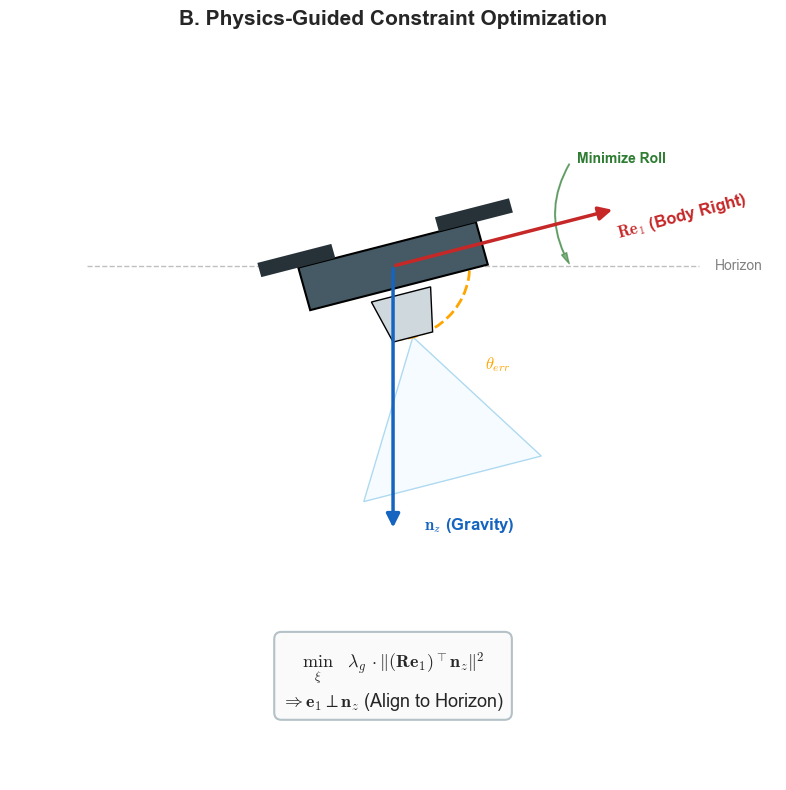

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch, Arc

# 设置风格
plt.style.use('seaborn-v0_8-white')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['mathtext.fontset'] = 'cm'

# 创建画布
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-3, 2)
ax.axis('off')

# ==========================================
# 0. 辅助函数：旋转变换
# ==========================================
def rotate_point(point, angle_deg, origin=(0, 0)):
    angle_rad = np.radians(angle_deg)
    ox, oy = origin
    px, py = point
    qx = ox + np.cos(angle_rad) * (px - ox) - np.sin(angle_rad) * (py - oy)
    qy = oy + np.sin(angle_rad) * (px - ox) + np.cos(angle_rad) * (py - oy)
    return np.array([qx, qy])

# 设定一个非零的 Roll 角，展示"被优化"的状态
roll_angle = 15  # 无人机向左倾斜 15 度
center = np.array([0, 0.5])

# ==========================================
# 1. 绘制环境 (Horizon)
# ==========================================
# 虚线地平线
ax.plot([-2, 2], [center[1], center[1]], color='gray', linestyle='--', linewidth=1, alpha=0.5, zorder=0)
ax.text(2.1, center[1], "Horizon", color='gray', fontsize=10, va='center')

# ==========================================
# 2. 绘制无人机 (UAV Icon)
# ==========================================
# 定义无人机组件 (未旋转前)
body_w, body_h = 1.2, 0.3
rotor_w, rotor_h = 0.5, 0.1
# 机身矩形四个角
body_rect = np.array([[-body_w/2, -body_h/2], [body_w/2, -body_h/2], 
                      [body_w/2, body_h/2], [-body_w/2, body_h/2]]) + center
# 左旋翼
rotor_l = np.array([[-body_w/2-rotor_w/2, body_h/2], [-body_w/2+rotor_w/2, body_h/2], 
                    [-body_w/2+rotor_w/2, body_h/2+rotor_h], [-body_w/2-rotor_w/2, body_h/2+rotor_h]]) + center
# 右旋翼
rotor_r = np.array([[body_w/2-rotor_w/2, body_h/2], [body_w/2+rotor_w/2, body_h/2], 
                    [body_w/2+rotor_w/2, body_h/2+rotor_h], [body_w/2-rotor_w/2, body_h/2+rotor_h]]) + center

# 旋转并绘制
rot_body = [rotate_point(p, roll_angle, center) for p in body_rect]
rot_rotor_l = [rotate_point(p, roll_angle, center) for p in rotor_l]
rot_rotor_r = [rotate_point(p, roll_angle, center) for p in rotor_r]

poly_body = patches.Polygon(rot_body, closed=True, fc='#455A64', ec='black', lw=1.5, zorder=5) # 深灰机身
poly_rot_l = patches.Polygon(rot_rotor_l, closed=True, fc='#263238', ec='none', zorder=5)
poly_rot_r = patches.Polygon(rot_rotor_r, closed=True, fc='#263238', ec='none', zorder=5)

ax.add_patch(poly_body)
ax.add_patch(poly_rot_l)
ax.add_patch(poly_rot_r)

# 绘制相机视锥 (挂载在机身下方)
cam_w = 0.4
cam_h = 0.3
cam_offset = np.array([0, -0.2])
# 相机梯形
cam_poly = np.array([[-cam_w/2, 0], [cam_w/2, 0], [cam_w/3, -cam_h], [-cam_w/3, -cam_h]]) + center + cam_offset
rot_cam = [rotate_point(p, roll_angle, center) for p in cam_poly]
ax.add_patch(patches.Polygon(rot_cam, closed=True, fc='#CFD8DC', ec='black', lw=1, zorder=4))

# 视场锥体 (Frustum) - 半透明
fov_len = 1.5
fov_w = 1.2
fov_pts = np.array([[0, -0.2-cam_h], [-fov_w/2, -fov_len], [fov_w/2, -fov_len]]) + center
rot_fov = [rotate_point(p, roll_angle, center) for p in fov_pts]
ax.add_patch(patches.Polygon(rot_fov, closed=True, fc='#E1F5FE', ec='#0288D1', lw=1, alpha=0.3, zorder=1))

# ==========================================
# 3. 绘制物理向量
# ==========================================
# 重力 n_z (始终垂直向下)
g_start = center
g_vec = np.array([0, -1.8])
g_end = g_start + g_vec
# 绘制重力箭头
arrow_g = FancyArrowPatch(posA=g_start, posB=g_end, arrowstyle='-|>', 
                          mutation_scale=20, color='#1565C0', lw=2.5, zorder=10)
ax.add_patch(arrow_g)
ax.text(g_end[0] + 0.2, g_end[1], r'$\mathbf{n}_z$ (Gravity)', color='#1565C0', fontsize=12, fontweight='bold')

# 相机右轴 e_1 (随机身旋转)
e1_vec_len = 1.5
e1_end_orig = center + np.array([e1_vec_len, 0])
e1_end = rotate_point(e1_end_orig, roll_angle, center)
# 绘制 e1 箭头
arrow_e1 = FancyArrowPatch(posA=center, posB=e1_end, arrowstyle='-|>', 
                           mutation_scale=20, color='#C62828', lw=2.5, zorder=10)
ax.add_patch(arrow_e1)
# ax.text(e1_end[0], e1_end[1]+0.2, r'$\mathbf{R}\mathbf{e}_1$ (Body Right)', color='#C62828', fontsize=12, fontweight='bold', rotation=roll_angle)
ax.text(e1_end[0], e1_end[1]-0.2, r'$\mathbf{R}\mathbf{e}_1$ (Body Right)', color='#C62828', fontsize=12, fontweight='bold', rotation=roll_angle)

# ==========================================
# 4. 绘制约束与优化指示
# ==========================================
# 绘制角度弧线 (展示当前的误差)
# e1 的角度是 roll_angle, n_z 的角度是 -90
# 我们想展示 e1 和 n_z 之间的角度并不是 90度
arc = Arc(center, width=1.0, height=1.0, angle=0, theta1=-90, theta2=roll_angle, 
          color='orange', lw=2, linestyle='--')
ax.add_patch(arc)

# 标注 "Error"
ax.text(0.6, -0.2, r'$\theta_{err}$', color='orange', fontsize=12)

# 绘制一个弯曲的箭头，指示"优化方向" (即把 e1 压回水平)
opt_arrow = FancyArrowPatch(posA=(e1_end[0]*0.8, e1_end[1]*0.8 + 0.5), 
                            posB=(e1_end[0]*0.8, center[1]), 
                            connectionstyle="arc3,rad=0.3",
                            arrowstyle='Simple, tail_width=0.5, head_width=4, head_length=8',
                            color='#2E7D32', alpha=0.6)
ax.add_patch(opt_arrow)
ax.text(1.2, 1.2, "Minimize Roll", color='#2E7D32', fontweight='bold', fontsize=10)

# ==========================================
# 5. 公式框
# ==========================================
bbox_props = dict(boxstyle="round,pad=0.4", fc="#FAFAFA", ec="#B0BEC5", lw=1.5, alpha=0.95)
formula = (r"$\min_{\xi} \quad \lambda_g \cdot \| (\mathbf{R}\mathbf{e}_1)^\top \mathbf{n}_z \|^2$" + "\n" +
           r"$\Rightarrow \mathbf{e}_1 \perp \mathbf{n}_z$ (Align to Horizon)")

ax.text(0, -2.5, formula, ha='center', fontsize=13, bbox=bbox_props)

# 标题
ax.set_title("B. Physics-Guided Constraint Optimization", fontsize=15, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(
    'Physics-Guided-Constraint-Optimization.png',  # 保存文件名
    dpi=300,                    # 分辨率，数值越高图片越清晰
    bbox_inches='tight',        # 裁剪多余空白区域
    pad_inches=0.1,             # 裁剪后保留少量边距
    transparent=True,           # 核心：设置背景透明
    facecolor='none'            # 再次确认画布背景透明
)

# plt.savefig('panel_b_optimized.pdf', bbox_inches='tight')
plt.show()

C:\Users\18038\AppData\Local\Temp\ipykernel_44628\1681419845.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


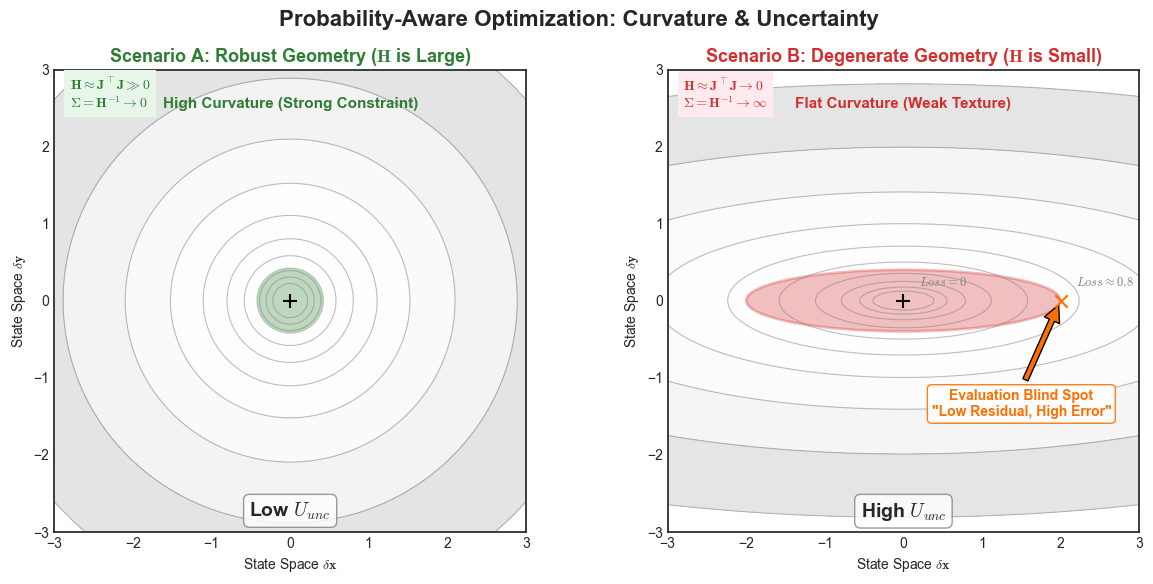

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

# 设置风格
plt.style.use('seaborn-v0_8-white')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['mathtext.fontset'] = 'cm'

# 创建画布
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.3)

# ==========================================
# 辅助函数：绘制损失地形与协方差
# ==========================================
def plot_loss_landscape(ax, curvature_type, title):
    # 1. 创建网格
    x = np.linspace(-3, 3, 100)
    y = np.linspace(-3, 3, 100)
    X, Y = np.meshgrid(x, y)
    
    # 2. 定义损失函数 Surface (模拟重投影误差)
    # Loss = 0.5 * (x^T H x)
    if curvature_type == 'sharp':
        # 陡峭地形 (高曲率): H 很大 -> Sigma 很小
        Z = 2.0 * X**2 + 2.0 * Y**2 
        sigma_width, sigma_height = 0.8, 0.8
        color_theme = '#2E7D32' # Green
        desc = "High Curvature (Strong Constraint)"
        unc_text = r"Low $U_{unc}$"
    else:
        # 平坦地形 (低曲率/退化): H 很小 -> Sigma 很大
        # 模拟沿 X 轴的不确定性 (例如沿着道路方向)
        Z = 0.2 * X**2 + 2.0 * Y**2 
        sigma_width, sigma_height = 4.0, 0.8 # 宽椭圆
        color_theme = '#D32F2F' # Red
        desc = "Flat Curvature (Weak Texture)"
        unc_text = r"High $U_{unc}$"
    
    # 3. 绘制等高线 (Loss Landscape)
    # 使用对数刻度让梯度更明显
    levels = np.logspace(-1, 1.5, 10)
    if curvature_type != 'sharp':
        # 平坦地形稍微调整level以便视觉对比
        levels = np.logspace(-1.5, 1.2, 10)
        
    cp = ax.contourf(X, Y, Z, levels=levels, cmap='Greys', alpha=0.15)
    ax.contour(X, Y, Z, levels=levels, colors='gray', linewidths=0.8, alpha=0.5)
    
    # 4. 绘制中心最优解
    ax.scatter(0, 0, c='black', marker='+', s=100, zorder=10, label='Optimal Estimate')
    
    # 5. 绘制后验协方差椭圆 (Sigma)
    # 椭圆大小代表不确定性范围 (3-sigma)
    ellipse = patches.Ellipse((0, 0), width=sigma_width, height=sigma_height, 
                              angle=0, fc=color_theme, alpha=0.3, ec=color_theme, lw=2)
    ax.add_patch(ellipse)
    
    # 6. 标注 "盲区" 概念 (仅在右图)
    if curvature_type == 'flat':
        # 找一个点：残差很低，但距离很远
        bad_pt = np.array([2.0, 0])
        ax.scatter(bad_pt[0], bad_pt[1], c='#FF6F00', marker='x', s=80, zorder=10)
        
        # 画箭头指示
        ax.annotate('Evaluation Blind Spot\n"Low Residual, High Error"', 
                    xy=(bad_pt[0], bad_pt[1]), xytext=(1.5, -1.5),
                    arrowprops=dict(facecolor='#FF6F00', shrink=0.05),
                    color='#FF6F00', fontweight='bold', ha='center',
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#FF6F00", alpha=0.9))
        
        # 标注残差对比
        ax.text(2.2, 0.2, r'$Loss \approx 0.8$', color='gray', fontsize=9)
        ax.text(0.2, 0.2, r'$Loss = 0$', color='gray', fontsize=9)

    # 7. 装饰
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_xlabel(r'State Space $\delta \mathbf{x}$', fontsize=10)
    ax.set_ylabel(r'State Space $\delta \mathbf{y}$', fontsize=10)
    ax.set_title(title, fontsize=13, fontweight='bold', color=color_theme)
    ax.text(0, 2.5, desc, ha='center', fontsize=11, fontweight='bold', color=color_theme)
    
    # 显示不确定性公式
    ax.text(0, -2.8, unc_text, ha='center', fontsize=14, fontweight='bold', 
            bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))

# ==========================================
# 绘制左图：Sharp Minima
# ==========================================
ax1 = fig.add_subplot(gs[0])
plot_loss_landscape(ax1, 'sharp', r"Scenario A: Robust Geometry ($\mathbf{H}$ is Large)")

# 添加数学解释
formula_sharp = (r"$\mathbf{H} \approx \mathbf{J}^\top\mathbf{J} \gg 0$" + "\n" +
                 r"$\mathbf{\Sigma} = \mathbf{H}^{-1} \to \mathbf{0}$")
ax1.text(-2.8, 2.5, formula_sharp, fontsize=10, color='#2E7D32', 
         bbox=dict(fc='#E8F5E9', ec='none'))

# ==========================================
# 绘制右图：Flat Minima
# ==========================================
ax2 = fig.add_subplot(gs[1])
plot_loss_landscape(ax2, 'flat', r"Scenario B: Degenerate Geometry ($\mathbf{H}$ is Small)")

# 添加数学解释
formula_flat = (r"$\mathbf{H} \approx \mathbf{J}^\top\mathbf{J} \to 0$" + "\n" +
                r"$\mathbf{\Sigma} = \mathbf{H}^{-1} \to \infty$")
ax2.text(-2.8, 2.5, formula_flat, fontsize=10, color='#D32F2F', 
         bbox=dict(fc='#FFEBEE', ec='none'))

# ==========================================
# 中间标题
# ==========================================
plt.suptitle("Probability-Aware Optimization: Curvature & Uncertainty", fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
# plt.savefig('uncertainty_curvature_vis.pdf', bbox_inches='tight')

plt.savefig(
    'Uncertainty.png',  # 保存文件名
    dpi=300,                    # 分辨率，数值越高图片越清晰
    bbox_inches='tight',        # 裁剪多余空白区域
    pad_inches=0.1,             # 裁剪后保留少量边距
    transparent=True,           # 核心：设置背景透明
    facecolor='none'            # 再次确认画布背景透明
)

plt.show()

C:\Users\18038\AppData\Local\Temp\ipykernel_44628\457164284.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


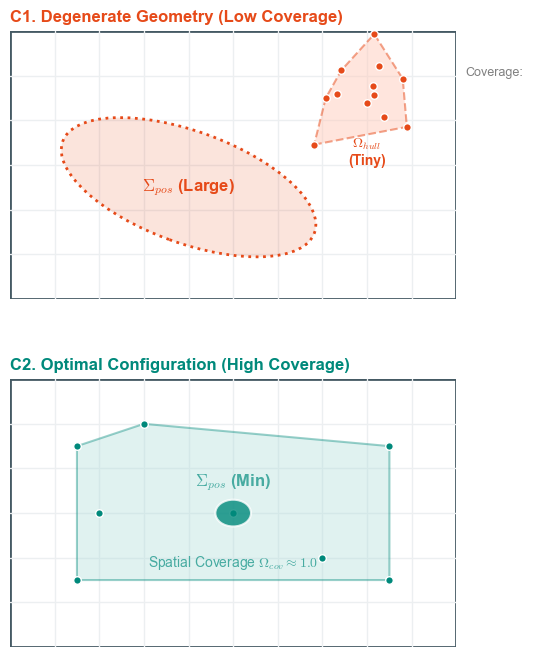

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.patches import Ellipse, Polygon
from scipy.spatial import ConvexHull

# 设置风格
plt.style.use('seaborn-v0_8-white')
plt.rcParams['font.family'] = 'sans-serif' 
plt.rcParams['mathtext.fontset'] = 'cm'    

# 创建画布
fig = plt.figure(figsize=(6, 8))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1], hspace=0.3)

# 定义颜色
c_bad_main = '#E64A19'   # 深橙色 (警示)
c_bad_light = '#FFCCBC'  # 浅橙色
c_good_main = '#00897B'  # 青色/翡翠绿 (安全)
c_good_light = '#B2DFDB' # 浅青色
c_frame = '#455A64'      # 边框深灰

# ==========================================
# 辅助函数：绘制相机视场背景 (已修复)
# ==========================================
def draw_camera_frame(ax, title, color_theme):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # 1. 绘制图像边框 (Image Plane)
    rect = patches.Rectangle((0, 0), 10, 6, linewidth=2, edgecolor=c_frame, facecolor='white', zorder=0)
    ax.add_patch(rect)
    
    # 2. 绘制微弱的像素网格 (暗示图像坐标系)
    for i in range(1, 10):
        ax.axvline(i, color='#ECEFF1', linewidth=1, zorder=0)
    for i in range(1, 6):
        ax.axhline(i, color='#ECEFF1', linewidth=1, zorder=0)
        
    # 3. 标题 (修复点：将 loc='left' 改为 ha='left')
    ax.text(0, 6.2, title, fontsize=12, fontweight='bold', color=color_theme, ha='left')

# ==========================================
# C1: Degenerate Geometry (High Uncertainty)
# ==========================================
ax1 = fig.add_subplot(gs[0])
draw_camera_frame(ax1, "C1. Degenerate Geometry (Low Coverage)", c_bad_main)

# 1. 生成聚集的数据点 (Clustered)
np.random.seed(10)
pts_bad = np.random.normal(loc=[8, 4.5], scale=0.6, size=(12, 2)) # 聚集在右上角
ax1.scatter(pts_bad[:,0], pts_bad[:,1], c=c_bad_main, s=30, zorder=10, edgecolors='white')

# 2. 计算并绘制凸包 (Convex Hull)
hull = ConvexHull(pts_bad)
hull_pts = pts_bad[hull.vertices]
poly_hull = Polygon(hull_pts, closed=True, fc=c_bad_light, ec=c_bad_main, 
                    linestyle='--', linewidth=1.5, alpha=0.5, zorder=5)
ax1.add_patch(poly_hull)

# 3. 绘制巨大的误差椭圆 (Uncertainty)
ell_bad = Ellipse((4, 2.5), width=6, height=2.5, angle=-20, 
                  fc=c_bad_main, alpha=0.15, ec=c_bad_main, lw=0, zorder=2)
# 加一个虚线边缘
ell_bad_stroke = Ellipse((4, 2.5), width=6, height=2.5, angle=-20, 
                         fill=False, ec=c_bad_main, linestyle=':', lw=2, zorder=2)
ax1.add_patch(ell_bad)
ax1.add_patch(ell_bad_stroke)

# 4. 文字标注
ax1.text(4, 2.5, r"$\mathbf{\Sigma}_{pos}$ (Large)", ha='center', va='center', color=c_bad_main, fontweight='bold', fontsize=12)
ax1.text(8, 3.0, r"$\Omega_{hull}$" + "\n(Tiny)", ha='center', color=c_bad_main, fontsize=10, fontweight='bold')

# 5. 右侧指标条 (Bar Indicator)
ax1.text(10.2, 5, "Coverage:", fontsize=9, color='gray')
rect_bar_bg = patches.Rectangle((10.2, 0.5), 0.3, 4, fc='#ECEFF1', ec='none')
rect_bar_val = patches.Rectangle((10.2, 0.5), 0.3, 0.5, fc=c_bad_main, ec='none') # Low value
ax1.add_patch(rect_bar_bg)
ax1.add_patch(rect_bar_val)


# ==========================================
# C2: Optimal Geometry (Low Uncertainty)
# ==========================================
ax2 = fig.add_subplot(gs[1])
draw_camera_frame(ax2, "C2. Optimal Configuration (High Coverage)", c_good_main)

# 1. 生成分散的数据点 (Distributed)
pts_good = np.array([
    [1.5, 1.5], [8.5, 1.5], [1.5, 4.5], [8.5, 4.5], # Corners
    [5.0, 3.0], [3.0, 5.0], [7.0, 2.0], [2.0, 3.0]  # Random distributed
])
ax2.scatter(pts_good[:,0], pts_good[:,1], c=c_good_main, s=30, zorder=10, edgecolors='white')

# 2. 计算并绘制凸包
hull2 = ConvexHull(pts_good)
hull_pts2 = pts_good[hull2.vertices]
poly_hull2 = Polygon(hull_pts2, closed=True, fc=c_good_light, ec=c_good_main, 
                     linestyle='-', linewidth=1.5, alpha=0.4, zorder=5)
ax2.add_patch(poly_hull2)

# 3. 绘制微小的误差椭圆
ell_good = Ellipse((5, 3), width=0.8, height=0.6, angle=0, 
                   fc=c_good_main, alpha=0.8, ec='white', lw=1.5, zorder=20)
ax2.add_patch(ell_good)

# 4. 文字标注
ax2.text(5, 3.6, r"$\mathbf{\Sigma}_{pos}$ (Min)", ha='center', color=c_good_main, fontweight='bold', fontsize=12)
ax2.text(5, 1.8, r"Spatial Coverage $\Omega_{cov} \approx 1.0$", ha='center', color=c_good_main, fontsize=10)

# 5. 右侧指标条
# ax2.text(10.2, 5, "Coverage:", fontsize=9, color='gray')
rect_bar_bg2 = patches.Rectangle((10.2, 0.5), 0.3, 4, fc='#ECEFF1', ec='none')
rect_bar_val2 = patches.Rectangle((10.2, 0.5), 0.3, 3.5, fc=c_good_main, ec='none') # High value
ax2.add_patch(rect_bar_bg2)
ax2.add_patch(rect_bar_val2)

plt.tight_layout()
# plt.savefig('panel_c_optimized.pdf', bbox_inches='tight')
plt.savefig(
    'Degenerate Geometry.png',  # 保存文件名
    dpi=300,                    # 分辨率，数值越高图片越清晰
    bbox_inches='tight',        # 裁剪多余空白区域
    pad_inches=0.1,             # 裁剪后保留少量边距
    transparent=True,           # 核心：设置背景透明
    facecolor='none'            # 再次确认画布背景透明
)


plt.show()

C:\Users\18038\AppData\Local\Temp\ipykernel_48648\457164284.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


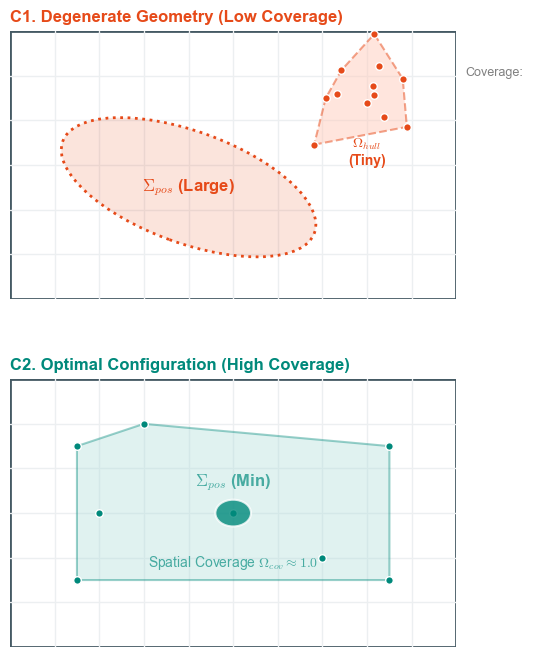

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.patches import Ellipse, Polygon
from scipy.spatial import ConvexHull

# 设置风格
plt.style.use('seaborn-v0_8-white')
plt.rcParams['font.family'] = 'sans-serif' 
plt.rcParams['mathtext.fontset'] = 'cm'    

# 创建画布
fig = plt.figure(figsize=(6, 8))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1], hspace=0.3)

# 定义颜色
c_bad_main = '#E64A19'   # 深橙色 (警示)
c_bad_light = '#FFCCBC'  # 浅橙色
c_good_main = '#00897B'  # 青色/翡翠绿 (安全)
c_good_light = '#B2DFDB' # 浅青色
c_frame = '#455A64'      # 边框深灰

# ==========================================
# 辅助函数：绘制相机视场背景 (已修复)
# ==========================================
def draw_camera_frame(ax, title, color_theme):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # 1. 绘制图像边框 (Image Plane)
    rect = patches.Rectangle((0, 0), 10, 6, linewidth=2, edgecolor=c_frame, facecolor='white', zorder=0)
    ax.add_patch(rect)
    
    # 2. 绘制微弱的像素网格 (暗示图像坐标系)
    for i in range(1, 10):
        ax.axvline(i, color='#ECEFF1', linewidth=1, zorder=0)
    for i in range(1, 6):
        ax.axhline(i, color='#ECEFF1', linewidth=1, zorder=0)
        
    # 3. 标题 (修复点：将 loc='left' 改为 ha='left')
    ax.text(0, 6.2, title, fontsize=12, fontweight='bold', color=color_theme, ha='left')

# ==========================================
# C1: Degenerate Geometry (High Uncertainty)
# ==========================================
ax1 = fig.add_subplot(gs[0])
draw_camera_frame(ax1, "C1. Degenerate Geometry (Low Coverage)", c_bad_main)

# 1. 生成聚集的数据点 (Clustered)
np.random.seed(10)
pts_bad = np.random.normal(loc=[8, 4.5], scale=0.6, size=(12, 2)) # 聚集在右上角
ax1.scatter(pts_bad[:,0], pts_bad[:,1], c=c_bad_main, s=30, zorder=10, edgecolors='white')

# 2. 计算并绘制凸包 (Convex Hull)
hull = ConvexHull(pts_bad)
hull_pts = pts_bad[hull.vertices]
poly_hull = Polygon(hull_pts, closed=True, fc=c_bad_light, ec=c_bad_main, 
                    linestyle='--', linewidth=1.5, alpha=0.5, zorder=5)
ax1.add_patch(poly_hull)

# 3. 绘制巨大的误差椭圆 (Uncertainty)
ell_bad = Ellipse((4, 2.5), width=6, height=2.5, angle=-20, 
                  fc=c_bad_main, alpha=0.15, ec=c_bad_main, lw=0, zorder=2)
# 加一个虚线边缘
ell_bad_stroke = Ellipse((4, 2.5), width=6, height=2.5, angle=-20, 
                         fill=False, ec=c_bad_main, linestyle=':', lw=2, zorder=2)
ax1.add_patch(ell_bad)
ax1.add_patch(ell_bad_stroke)

# 4. 文字标注
ax1.text(4, 2.5, r"$\mathbf{\Sigma}_{pos}$ (Large)", ha='center', va='center', color=c_bad_main, fontweight='bold', fontsize=12)
ax1.text(8, 3.0, r"$\Omega_{hull}$" + "\n(Tiny)", ha='center', color=c_bad_main, fontsize=10, fontweight='bold')

# 5. 右侧指标条 (Bar Indicator)
ax1.text(10.2, 5, "Coverage:", fontsize=9, color='gray')
rect_bar_bg = patches.Rectangle((10.2, 0.5), 0.3, 4, fc='#ECEFF1', ec='none')
rect_bar_val = patches.Rectangle((10.2, 0.5), 0.3, 0.5, fc=c_bad_main, ec='none') # Low value
ax1.add_patch(rect_bar_bg)
ax1.add_patch(rect_bar_val)


# ==========================================
# C2: Optimal Geometry (Low Uncertainty)
# ==========================================
ax2 = fig.add_subplot(gs[1])
draw_camera_frame(ax2, "C2. Optimal Configuration (High Coverage)", c_good_main)

# 1. 生成分散的数据点 (Distributed)
pts_good = np.array([
    [1.5, 1.5], [8.5, 1.5], [1.5, 4.5], [8.5, 4.5], # Corners
    [5.0, 3.0], [3.0, 5.0], [7.0, 2.0], [2.0, 3.0]  # Random distributed
])
ax2.scatter(pts_good[:,0], pts_good[:,1], c=c_good_main, s=30, zorder=10, edgecolors='white')

# 2. 计算并绘制凸包
hull2 = ConvexHull(pts_good)
hull_pts2 = pts_good[hull2.vertices]
poly_hull2 = Polygon(hull_pts2, closed=True, fc=c_good_light, ec=c_good_main, 
                     linestyle='-', linewidth=1.5, alpha=0.4, zorder=5)
ax2.add_patch(poly_hull2)

# 3. 绘制微小的误差椭圆
ell_good = Ellipse((5, 3), width=0.8, height=0.6, angle=0, 
                   fc=c_good_main, alpha=0.8, ec='white', lw=1.5, zorder=20)
ax2.add_patch(ell_good)

# 4. 文字标注
ax2.text(5, 3.6, r"$\mathbf{\Sigma}_{pos}$ (Min)", ha='center', color=c_good_main, fontweight='bold', fontsize=12)
ax2.text(5, 1.8, r"Spatial Coverage $\Omega_{cov} \approx 1.0$", ha='center', color=c_good_main, fontsize=10)

# 5. 右侧指标条
# ax2.text(10.2, 5, "Coverage:", fontsize=9, color='gray')
rect_bar_bg2 = patches.Rectangle((10.2, 0.5), 0.3, 4, fc='#ECEFF1', ec='none')
rect_bar_val2 = patches.Rectangle((10.2, 0.5), 0.3, 3.5, fc=c_good_main, ec='none') # High value
ax2.add_patch(rect_bar_bg2)
ax2.add_patch(rect_bar_val2)

plt.tight_layout()
# plt.savefig('panel_c_optimized.pdf', bbox_inches='tight')
plt.savefig(
    'Degenerate Geometry.png',  # 保存文件名
    dpi=300,                    # 分辨率，数值越高图片越清晰
    bbox_inches='tight',        # 裁剪多余空白区域
    pad_inches=0.1,             # 裁剪后保留少量边距
    transparent=True,           # 核心：设置背景透明
    facecolor='none'            # 再次确认画布背景透明
)


plt.show()

C:\Users\18038\AppData\Local\Temp\ipykernel_34560\1828866942.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


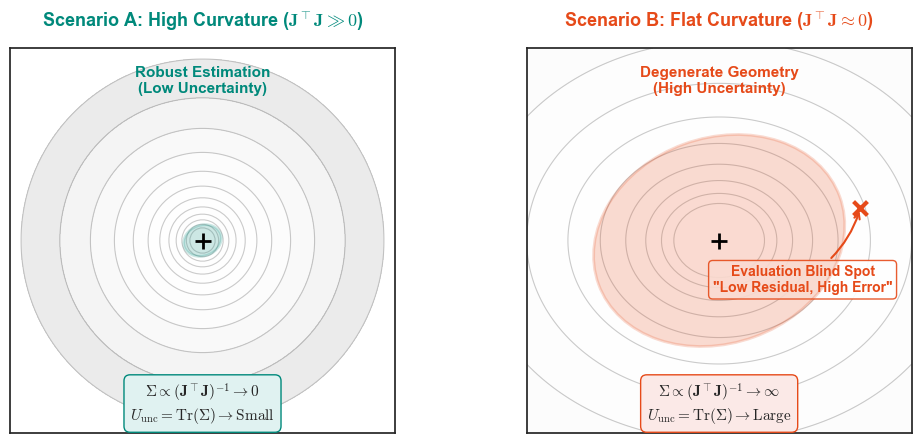

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

# 设置风格
plt.style.use('seaborn-v0_8-white')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['mathtext.fontset'] = 'cm'

# 创建画布
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)

# ==========================================
# 辅助函数：绘制地形与协方差
# ==========================================
def plot_fisher_landscape(ax, mode):
    # 1. 创建网格
    x = np.linspace(-3, 3, 100)
    y = np.linspace(-3, 3, 100)
    X, Y = np.meshgrid(x, y)
    
    if mode == 'robust':
        # 陡峭地形 (High Curvature)
        # J^T J 很大 -> 曲率大
        Z = 2.5 * X**2 + 2.5 * Y**2
        title = r"Scenario A: High Curvature ($\mathbf{J}^\top \mathbf{J} \gg 0$)"
        color = '#00897B' # Teal
        sigma_scale = 0.6
        desc = "Robust Estimation\n(Low Uncertainty)"
    else:
        # 平坦地形 (Low Curvature / Degenerate)
        # J^T J 很小 -> 曲率小
        Z = 0.2 * X**2 + 0.3 * Y**2 # 非常平坦
        title = r"Scenario B: Flat Curvature ($\mathbf{J}^\top \mathbf{J} \approx 0$)"
        color = '#E64A19' # Deep Orange
        sigma_scale = 4.0 # 巨大的不确定性
        desc = "Degenerate Geometry\n(High Uncertainty)"

    # 2. 绘制等高线 (Loss Landscape)
    # 使用对数刻度让平坦区域的等高线也能显示出来
    levels = np.geomspace(0.1, 20, 12)
    ax.contourf(X, Y, Z, levels=levels, cmap='Greys', alpha=0.1)
    cs = ax.contour(X, Y, Z, levels=levels, colors='gray', linewidths=0.8, alpha=0.4)
    
    # 3. 绘制最优解 (Ground Truth / Opt)
    ax.scatter(0, 0, c='black', marker='+', s=120, lw=2, zorder=10, label='Optimal Solution')
    
    # 4. 绘制后验协方差椭圆 (Sigma)
    # Sigma ~ (J^T J)^-1. 曲率越小，椭圆越大
    ellipse = patches.Ellipse((0, 0), width=sigma_scale, height=sigma_scale*0.8, 
                              angle=20, fc=color, alpha=0.2, ec=color, lw=2, zorder=5)
    ax.add_patch(ellipse)
    
    # 5. 标注 "盲区" (仅在右图)
    if mode == 'degenerate':
        # 找一个点：Error很大(距离远)，但Residual很小(Z值低)
        bad_x, bad_y = 2.2, 0.5
        bad_z = 0.2 * bad_x**2 + 0.3 * bad_y**2 # 约 1.0
        
        ax.scatter(bad_x, bad_y, c=color, marker='x', s=100, lw=3, zorder=10)
        
        # 绘制箭头和文字
        ax.annotate('Evaluation Blind Spot\n"Low Residual, High Error"', 
                    xy=(bad_x, bad_y), xytext=(1.3, -0.8),
                    arrowprops=dict(arrowstyle="->", color=color, lw=1.5, connectionstyle="arc3,rad=0.2"),
                    color=color, fontweight='bold', ha='center',
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.9))
        
        # 对比残差
        # ax.text(bad_x-50.1, bad_y, r'$Loss \approx \epsilon$', color='gray', fontsize=9)

    # 6. 设置装饰
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')
    
    # 标题与公式
    ax.set_title(title, fontsize=13, fontweight='bold', color=color, pad=15)
    
    # 在左下角/右下角显示数学含义
    if mode == 'robust':
        formula = (r"$\mathbf{\Sigma} \propto (\mathbf{J}^\top \mathbf{J})^{-1} \to \mathbf{0}$" + "\n" +
                   r"$U_{\text{unc}} = \mathrm{Tr}(\mathbf{\Sigma}) \to \mathrm{Small}$")
        bg_color = '#E0F2F1'
    else:
        formula = (r"$\mathbf{\Sigma} \propto (\mathbf{J}^\top \mathbf{J})^{-1} \to \infty$" + "\n" +
                   r"$U_{\text{unc}} = \mathrm{Tr}(\mathbf{\Sigma}) \to \mathrm{Large}$")
        bg_color = '#FBE9E7'

    ax.text(0, 2.3, desc, ha='center', fontsize=11, fontweight='bold', color=color)
    
    ax.text(0, -2.8, formula, ha='center', fontsize=11, 
            bbox=dict(boxstyle="round,pad=0.4", fc=bg_color, ec=color, lw=1))

# ==========================================
# 绘制两个子图
# ==========================================
ax1 = fig.add_subplot(gs[0])
plot_fisher_landscape(ax1, 'robust')

ax2 = fig.add_subplot(gs[1])
plot_fisher_landscape(ax2, 'degenerate')

# plt.suptitle("Geometric Interpretation: Fisher Information & Posterior Uncertainty", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
# plt.savefig('fisher_information_visualization.pdf', bbox_inches='tight')
plt.savefig(
    'Uncertainty.png',  # 保存文件名
    dpi=300,                    # 分辨率，数值越高图片越清晰
    bbox_inches='tight',        # 裁剪多余空白区域
    pad_inches=0.1,             # 裁剪后保留少量边距
    transparent=True,           # 核心：设置背景透明
    facecolor='none'            # 再次确认画布背景透明
)


plt.show()

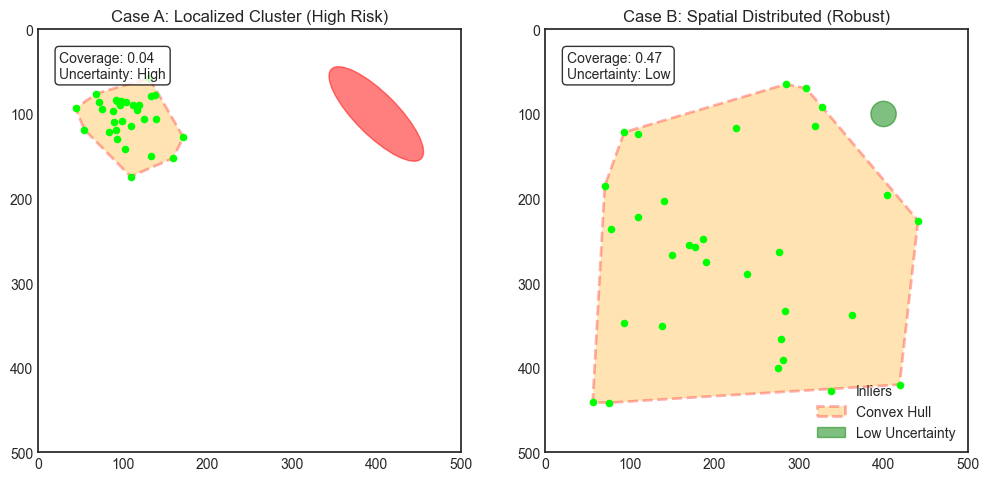

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "d:\Anaconda\anaconda3\envs\Thermal2Loc\Lib\asyncio\events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Anaconda\anaconda3\envs\Thermal2Loc\Lib\asyncio\selector_events.py", line 132, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 远程主机强迫关闭了一个现有的连接。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "d:\Anaconda\anaconda3\envs\Thermal2Loc\Lib\asyncio\events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Anaconda\anaconda3\envs\Thermal2Loc\Lib\asyncio\selector_events.py", line 132, in _read_from_self
   

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import ConvexHull
from matplotlib.patches import Polygon, Ellipse

def draw_visualization(ax, points, img_shape, title):
    # 1. 绘制底图框
    ax.set_xlim(0, img_shape[1])
    ax.set_ylim(img_shape[0], 0)
    ax.set_aspect('equal')
    
    # 2. 绘制内点
    ax.scatter(points[:, 0], points[:, 1], c='lime', s=20, label='Inliers', zorder=3)
    
    # 3. 计算并绘制凸包 (Spatial Coverage)
    hull = ConvexHull(points)
    hull_points = points[hull.vertices]
    poly = Polygon(hull_points, closed=True, facecolor='orange', alpha=0.3, edgecolor='red', linestyle='--', linewidth=2, label='Convex Hull')
    ax.add_patch(poly)
    
    # 计算面积比
    hull_area = hull.volume # 2D中volume即面积
    img_area = img_shape[0] * img_shape[1]
    coverage_ratio = hull_area / img_area
    
    # 4. 模拟绘制不确定性椭圆 (示意图)
    # 聚集的点导致大的不确定性，分散的点导致小的不确定性
    if coverage_ratio < 0.2:
        cov_ellipse = Ellipse((img_shape[1]-100, 100), width=150, height=50, angle=45, color='red', alpha=0.5, label='High Uncertainty')
    else:
        cov_ellipse = Ellipse((img_shape[1]-100, 100), width=30, height=30, color='green', alpha=0.5, label='Low Uncertainty')
    ax.add_patch(cov_ellipse)
    
    # 5. 添加文字说明
    text_str = f'Coverage: {coverage_ratio:.2f}\nUncertainty: {"High" if coverage_ratio < 0.2 else "Low"}'
    ax.text(0.05, 0.95, text_str, transform=ax.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_title(title)

# --- 模拟数据 ---
img_shape = (500, 500)

# Case A: 聚集在左上角
points_clustered = np.random.normal(loc=[100, 100], scale=30, size=(30, 2))
# Case B: 均匀分布
points_spread = np.random.uniform(low=50, high=450, size=(30, 2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

draw_visualization(ax1, points_clustered, img_shape, "Case A: Localized Cluster (High Risk)")
draw_visualization(ax2, points_spread, img_shape, "Case B: Spatial Distributed (Robust)")

plt.legend(loc='lower right')
plt.show()